<a href="https://colab.research.google.com/github/Tejaswini-AnalyticsExpert/Data-Cleaning-Preprocessing/blob/main/Demand%20Forecasting%20Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                            OLS Regression Results                            
Dep. Variable:            ln_quantity   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     118.4
Date:                Fri, 08 May 2026   Prob (F-statistic):           4.03e-27
Time:                        14:30:38   Log-Likelihood:                -3784.7
No. Observations:                3289   AIC:                             7573.
Df Residuals:                    3287   BIC:                             7586.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0198      0.221     22.691      0.0

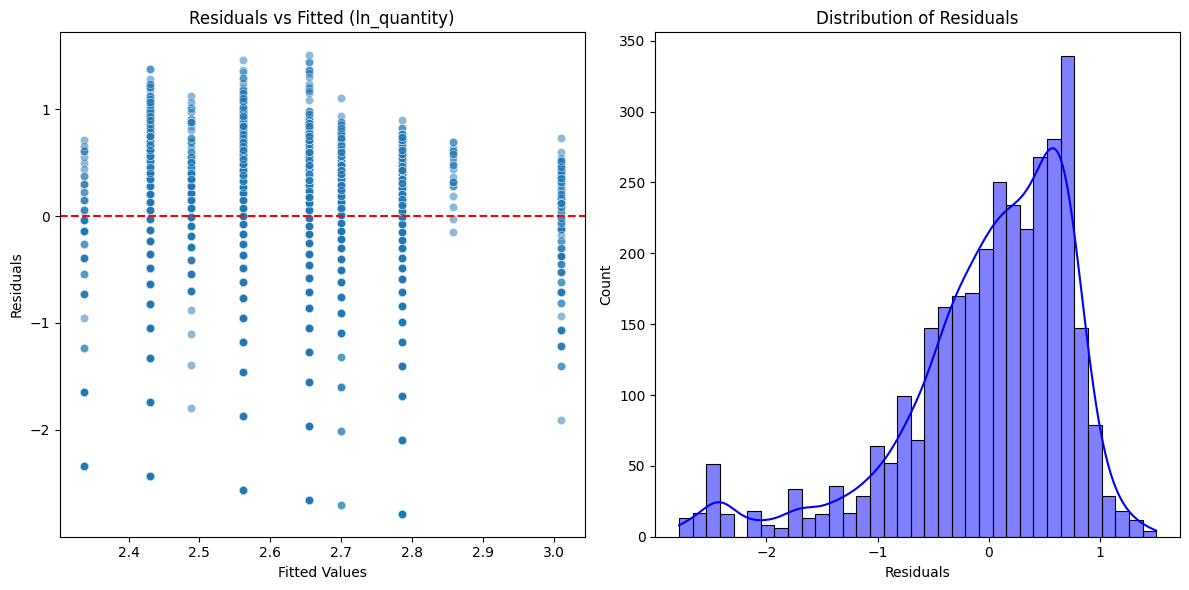

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# 1. Load the dataset
# Ensure the file 'Cleaned_Fitness_Data_2018.csv' is in the working directory
df = pd.read_csv('Cleaned_Fitness_Data_2018.csv')

# 2. Data Preparation for Modeling
# Filter out any non-positive values to ensure log transformation is valid
df = df[(df['Price (INR)'] > 0) & (df['Number Booked'] > 0)].copy()

# Create logarithmic features for the Log-Log model
# Formula: ln(Quantity) = intercept + beta * ln(Price)
df['ln_price'] = np.log(df['Price (INR)'])
df['ln_quantity'] = np.log(df['Number Booked'])

# 3. Build the Price Elasticity Model
# Independent variable (X) and Dependent variable (y)
X = df[['ln_price']]
X = sm.add_constant(X)  # Adds an intercept (alpha) to the model
y = df['ln_quantity']

# Fit the OLS (Ordinary Least Squares) regression
model = sm.OLS(y, X).fit()

# Display the regression results summary
print(model.summary())

# 4. Validate the Model
# Generate predictions
df['predictions'] = model.predict(X)
df['residuals'] = model.resid

# Calculate Metrics
mse = mean_squared_error(y, df['predictions'])
r_squared = model.rsquared

print(f"\nModel Validation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared: {r_squared:.4f}")
print(f"Price Elasticity Coefficient: {model.params['ln_price']:.4f}")

# 5. Visual Validation (Residual Plots)
plt.figure(figsize=(12, 6))

# Plot 1: Residuals vs. Fitted Values
# Used to check for homoscedasticity and non-linear patterns
plt.subplot(1, 2, 1)
sns.scatterplot(x='predictions', y='residuals', data=df, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted (ln_quantity)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

# Plot 2: Distribution of Residuals
# Used to check for normality of error terms
plt.subplot(1, 2, 2)
sns.histplot(df['residuals'], kde=True, color='blue')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')

plt.tight_layout()
plt.savefig('price_elasticity_validation.png')
plt.show()

# 6. Export Results
# Save the final data with predictions for further analysis
df.to_csv('Price_Elasticity_Predictions.csv', index=False)

**1. High-Demand Class and Time Identification**

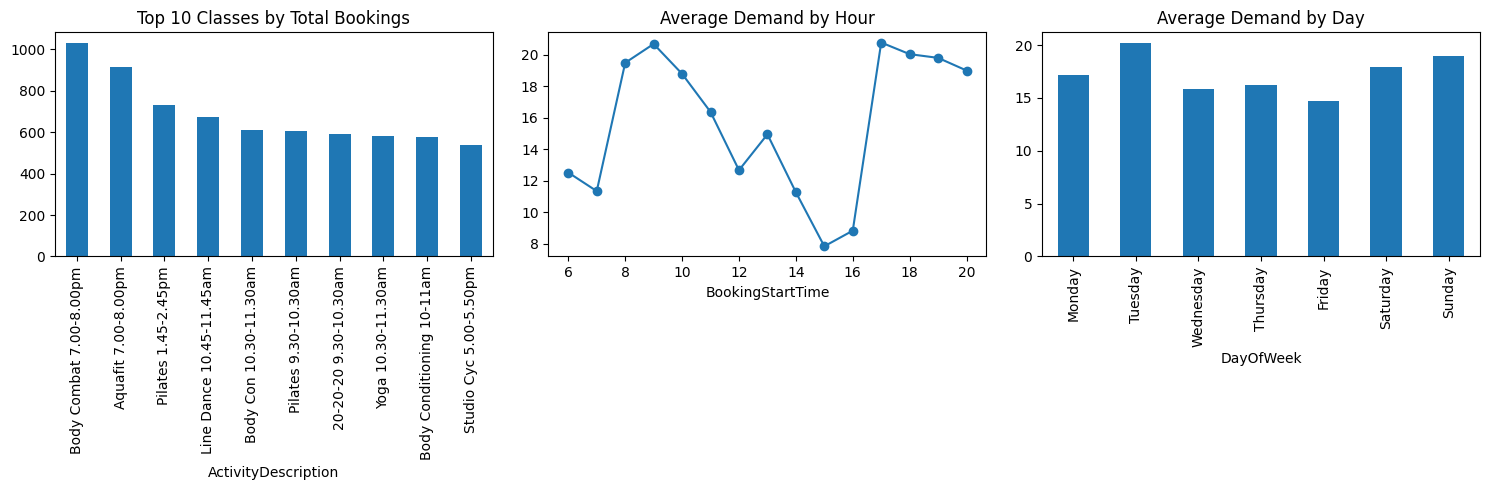

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load and prepare data
df = pd.read_csv('Cleaned_Fitness_Data_2018.csv')
df['BookingStartTime'] = pd.to_datetime(df['BookingStartTime'], format='%H:%M:%S').dt.hour

# Identify High-Demand Classes
top_classes = df.groupby('ActivityDescription')['Number Booked'].sum().sort_values(ascending=False).head(10)

# Identify Peak Times
peak_times = df.groupby('BookingStartTime')['Number Booked'].mean()

# Identify High-Demand Days
df['DayOfWeek'] = pd.to_datetime(df['BookingEndDateTime (Month / Day / Year)']).dt.day_name()
peak_days = df.groupby('DayOfWeek')['Number Booked'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)

# Plotting Peak Factors
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
top_classes.plot(kind='bar', title='Top 10 Classes by Total Bookings')
plt.subplot(1, 3, 2)
peak_times.plot(kind='line', marker='o', title='Average Demand by Hour')
plt.subplot(1, 3, 3)
peak_days.plot(kind='bar', title='Average Demand by Day')
plt.tight_layout()
plt.show()

2. Development of Dynamic Pricing Algorithm
Using the Price Elasticity (-0.32) and Demand Forecasts identified previously, we can define logic-based rules to adjust prices in real-time.

Pricing Rules:

Surge Pricing: If forecasted demand is > 80% of MaxBookees, increase price by 15%.

Early Bird/Low Demand: If forecasted demand is < 30% of MaxBookees, decrease price by 10% to stimulate interest (utilizing the inelastic nature of the demand).

Prime Time Premium: Add a fixed 5% increase for classes between 5:00 PM and 8:00 PM.

In [ ]:
def dynamic_pricing_engine(row):
    base_price = row['Price (INR)']
    capacity_usage = row['Forecasted_Demand'] / row['MaxBookees']
    new_price = base_price

    # Rule 1: High Occupancy (Surge)
    if capacity_usage > 0.80:
        new_price *= 1.15

    # Rule 2: Low Occupancy (Discount)
    elif capacity_usage < 0.30:
        new_price *= 0.90

    # Rule 3: Peak Hour Adjustment (17:00 - 20:00)
    if 17 <= row['BookingStartTime'] <= 20:
        new_price *= 1.05

    return round(new_price, 2)

# Apply the logic to simulate adjustments
# Assuming 'forecast_results' contains our SARIMA output joined with class metadata
# simulation_df['Dynamic_Price'] = simulation_df.apply(dynamic_pricing_engine, axis=1)

In [ ]:
def dynamic_pricing_engine(row):
    base_price = row['Price (INR)']
    capacity_usage = row['Forecasted_Demand'] / row['MaxBookees']
    new_price = base_price

    # Rule 1: High Occupancy (Surge)
    if capacity_usage > 0.80:
        new_price *= 1.15

    # Rule 2: Low Occupancy (Discount)
    elif capacity_usage < 0.30:
        new_price *= 0.90

    # Rule 3: Peak Hour Adjustment (17:00 - 20:00)
    if 17 <= row['BookingStartTime'] <= 20:
        new_price *= 1.05

    return round(new_price, 2)

# Apply the logic to simulate adjustments
# Assuming 'forecast_results' contains our SARIMA output joined with class metadata
# simulation_df['Dynamic_Price'] = simulation_df.apply(dynamic_pricing_engine, axis=1)

In [ ]:
# Effectiveness Metrics
# Revenue = Price * Quantity
# Note: We adjust 'Quantity' based on our Elasticity (-0.32) when price changes
def simulate_demand_change(old_price, new_price, old_quantity, elasticity=-0.32):
    percentage_change_price = (new_price - old_price) / old_price
    percentage_change_quantity = percentage_change_price * elasticity
    new_quantity = old_quantity * (1 + percentage_change_quantity)
    return new_quantity

# Calculation of simulated Revenue vs Actual Revenue
# actual_rev = df['Price (INR)'] * df['Number Booked']
# predicted_rev = df['Dynamic_Price'] * df['Simulated_Quantity']

Dataset Range: 2018-04-01 00:00:00 to 2018-06-30 00:00:00


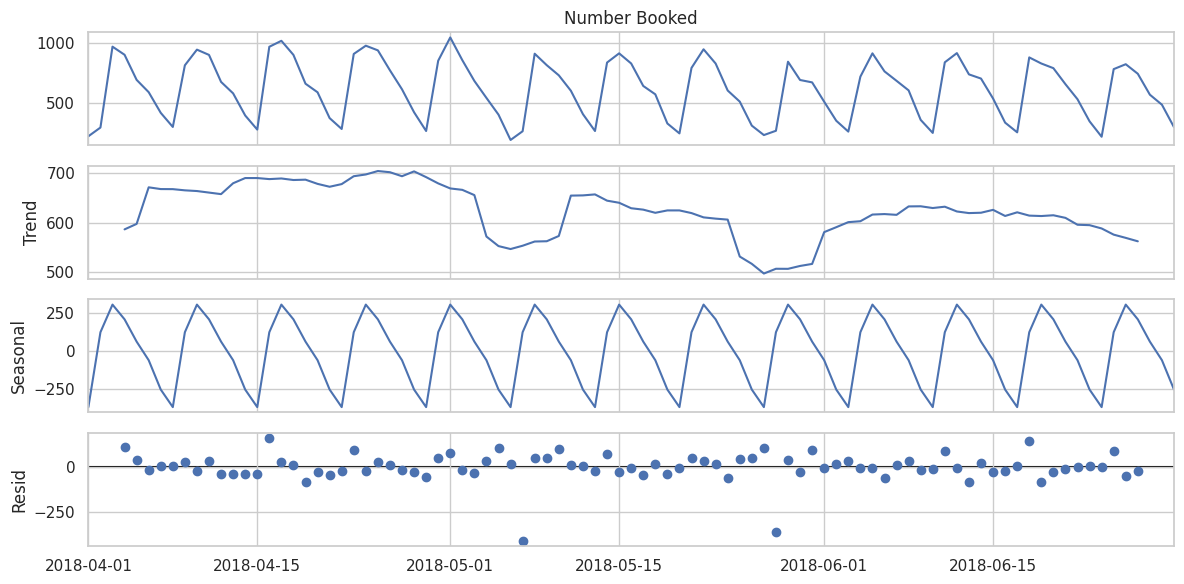

                                     SARIMAX Results                                     
Dep. Variable:                     Number Booked   No. Observations:                   72
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -339.715
Date:                           Fri, 08 May 2026   AIC                            689.429
Time:                                   15:14:36   BIC                            699.466
Sample:                               04-01-2018   HQIC                           693.311
                                    - 06-11-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2342      0.226      1.038      0.299      -0.208       0.677
ma.L1         -0.9025      0.188     -4.790

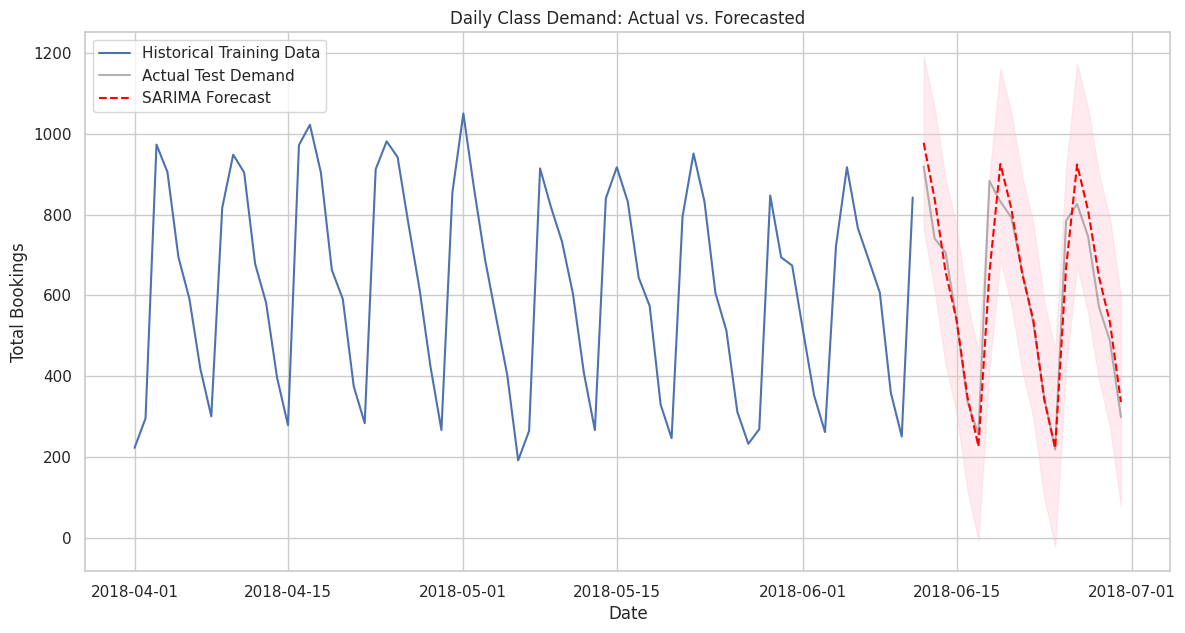

In [11]:
# %% [markdown]
# # Demand Forecasting Model Development
# This notebook builds a time-series forecasting model to predict daily attendance
# (demand) for fitness classes, enabling proactive dynamic pricing adjustments.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# %% [markdown]
# ## 1. Prepare Time Series Data
# We aggregate individual booking entries into a daily time series.

# %%
# Load dataset
df = pd.read_csv('Cleaned_Fitness_Data_2018.csv')

# Convert to datetime and set as index
df['Date'] = pd.to_datetime(df['BookingEndDateTime (Month / Day / Year)'])
daily_demand = df.groupby('Date')['Number Booked'].sum().reset_index()
daily_demand = daily_demand.set_index('Date')

# Ensure frequency is set to Daily and fill missing dates with 0
daily_demand = daily_demand.asfreq('D').fillna(0)

print(f"Dataset Range: {daily_demand.index.min()} to {daily_demand.index.max()}")
daily_demand.head()

# %% [markdown]
# ## 2. Exploratory Data Analysis (EDA) & Decomposition
# We analyze the series for seasonality (weekly patterns) and trends.

# %%
# Decompose the time series (7-day period for weekly seasonality)
decomposition = seasonal_decompose(daily_demand['Number Booked'], model='additive', period=7)

fig = decomposition.plot()
plt.show()

# %% [markdown]
# ## 3. Select and Train Forecasting Model (SARIMA)
# We use SARIMA (Seasonal Autoregressive Integrated Moving Average) to capture
# both the daily fluctuations and the weekly seasonal cycles.

# %%
# Split data into Training (80%) and Testing (20%)
train_size = int(len(daily_demand) * 0.8)
train, test = daily_demand.iloc[:train_size], daily_demand.iloc[train_size:]

# Initialize and Fit SARIMAX
# (p,d,q) = (1,1,1) | (P,D,Q,s) = (1,1,1,7)
model = SARIMAX(train['Number Booked'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

sarima_results = model.fit(disp=False)
print(sarima_results.summary())

# %% [markdown]
# ## 4. Generate and Validate Forecasts
# We predict the values for the test period and evaluate against actuals.

# %%
# Generate Forecast
forecast_obj = sarima_results.get_forecast(steps=len(test))
forecast_df = forecast_obj.summary_frame()

# Metrics Calculation
mae = mean_absolute_error(test['Number Booked'], forecast_df['mean'])
rmse = np.sqrt(mean_squared_error(test['Number Booked'], forecast_df['mean']))

print(f"Validation Metrics:\nMAE: {mae:.2f}\nRMSE: {rmse:.2f}")

# %% [markdown]
# ## 5. Visualization of Results
# Comparison of Training data, Test data, and the Model's Forecast.

# %%
plt.figure(figsize=(14, 7))
plt.plot(train.index, train['Number Booked'], label='Historical Training Data')
plt.plot(test.index, test['Number Booked'], label='Actual Test Demand', color='gray', alpha=0.6)
plt.plot(test.index, forecast_df['mean'], label='SARIMA Forecast', color='red', linestyle='--')

# Plot Confidence Intervals
plt.fill_between(test.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink', alpha=0.3)

plt.title('Daily Class Demand: Actual vs. Forecasted')
plt.xlabel('Date')
plt.ylabel('Total Bookings')
plt.legend()
plt.show()